In [26]:
# =============================================================================
# CELL 1 — Imports & Data Loading
# =============================================================================
!pip install stumpy --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stumpy
from scipy import stats as sp_stats
from scipy.spatial.distance import euclidean
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

raw = np.load('X_train_raw.npy', allow_pickle=False)
if raw.ndim == 3 and raw.shape[1] == 200 and raw.shape[2] == 7:
    X_train_raw = raw
else:
    y_train_tmp = np.load('y_train.npy')
    N = len(y_train_tmp)
    X_train_raw = raw.reshape(N, 200, 7)

y_train = np.load('y_train.npy')
idx_enmo = 3

print(f"X_train_raw shape : {X_train_raw.shape}")
print(f"y_train shape     : {y_train.shape}")

X_train_raw shape : (3355, 200, 7)
y_train shape     : (3355,)


In [27]:
# =============================================================================
# CELL 2 — Helper: Z‑normalise a 1D series (float64)
# =============================================================================
def z_norm(ts):
    ts = ts.astype(np.float64)
    std = np.std(ts)
    if std > 0:
        return (ts - np.mean(ts)) / std
    else:
        return ts - np.mean(ts)

Selected window size m = 10 (separation = 0.749)


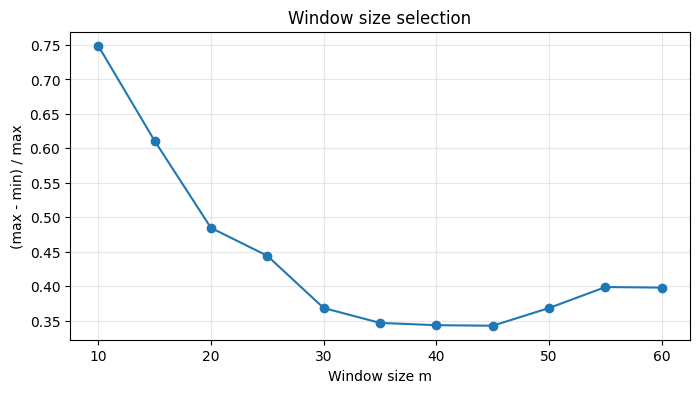

In [28]:
# =============================================================================
# CELL 3 — Systematic window size selection (using one healthy subject)
# =============================================================================
# Choose a representative subject (first healthy)
subj_example = np.where(y_train == 0)[0][0]
ts_example = z_norm(X_train_raw[subj_example, :, idx_enmo])

m_candidates = np.arange(10, 61, 5)
scores = []

for m in m_candidates:
    mp = stumpy.stump(ts_example, m)
    mp_vals = mp[:, 0]
    separation = (np.max(mp_vals) - np.min(mp_vals)) / (np.max(mp_vals) + 1e-8)
    scores.append(separation)

best_m = m_candidates[np.argmax(scores)]
m = best_m
print(f"Selected window size m = {m} (separation = {max(scores):.3f})")

plt.figure(figsize=(8, 4))
plt.plot(m_candidates, scores, marker='o')
plt.xlabel('Window size m')
plt.ylabel('(max - min) / max')
plt.title('Window size selection')
plt.grid(alpha=0.3)
plt.show()

In [29]:
# =============================================================================
# CELL 4 — Build concatenated series (50 healthy + 50 problematic)
# =============================================================================
np.random.seed(42)
n_per_class = 50
idx_0 = np.random.choice(np.where(y_train == 0)[0], n_per_class, replace=False)
idx_1 = np.random.choice(np.where(y_train == 1)[0], n_per_class, replace=False)
all_idx = np.concatenate([idx_0, idx_1])
all_labels = np.array([0]*n_per_class + [1]*n_per_class)

series_list = []
for subj in all_idx:
    ts = X_train_raw[subj, :, idx_enmo].astype(np.float64)
    ts = z_norm(ts)
    series_list.append(ts)

T = np.concatenate(series_list)                     # (200*100,)
T_labels = np.array([all_labels[i//200] for i in range(len(T))])
subj_ends = np.cumsum([200] * len(all_idx))

print(f"Concatenated series length: {len(T)}")

Concatenated series length: 20000


In [30]:
# =============================================================================
# CELL 5 — Matrix Profile on concatenated series
# =============================================================================
print(f"Computing Matrix Profile (n={len(T)}, m={m}) ...")
mp = stumpy.stump(T, m)
MP = mp[:, 0].astype(np.float64)
MPI = mp[:, 1].astype(int)

print(f"MP min (motif): {MP.min():.4f} at index {MP.argmin()}")
print(f"MP max (discord): {MP.max():.4f} at index {MP.argmax()}")

Computing Matrix Profile (n=20000, m=10) ...
MP min (motif): 0.0000 at index 1961
MP max (discord): 2.0082 at index 17561


In [35]:
# =============================================================================
# CELL 6 — Per‑subject regularity & discord scores (no skipping)
# =============================================================================
reg_scores = []
disc_scores = []
subj_labels = []
motif_positions = []

for i in range(len(X_train_raw)):
    ts = z_norm(X_train_raw[i, :, idx_enmo])
    mp_i = stumpy.stump(ts, m)
    mp_dist = mp_i[:, 0].astype(np.float64)
    # Replace inf with nan for safe min/max
    mp_dist = np.where(np.isinf(mp_dist), np.nan, mp_dist)
    min_val = np.nanmin(mp_dist)
    max_val = np.nanmax(mp_dist)
    best_idx = np.nanargmin(mp_dist)
    reg_scores.append(min_val)
    disc_scores.append(max_val)
    subj_labels.append(y_train[i])
    motif_positions.append(best_idx)
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(X_train_raw)} done")

reg = np.array(reg_scores, dtype=np.float64)
disc = np.array(disc_scores, dtype=np.float64)
lbl = np.array(subj_labels, dtype=int)

# rest of statistical test and plots unchanged ...

  500/3355 done
  1000/3355 done
  1500/3355 done
  2000/3355 done
  2500/3355 done
  3000/3355 done


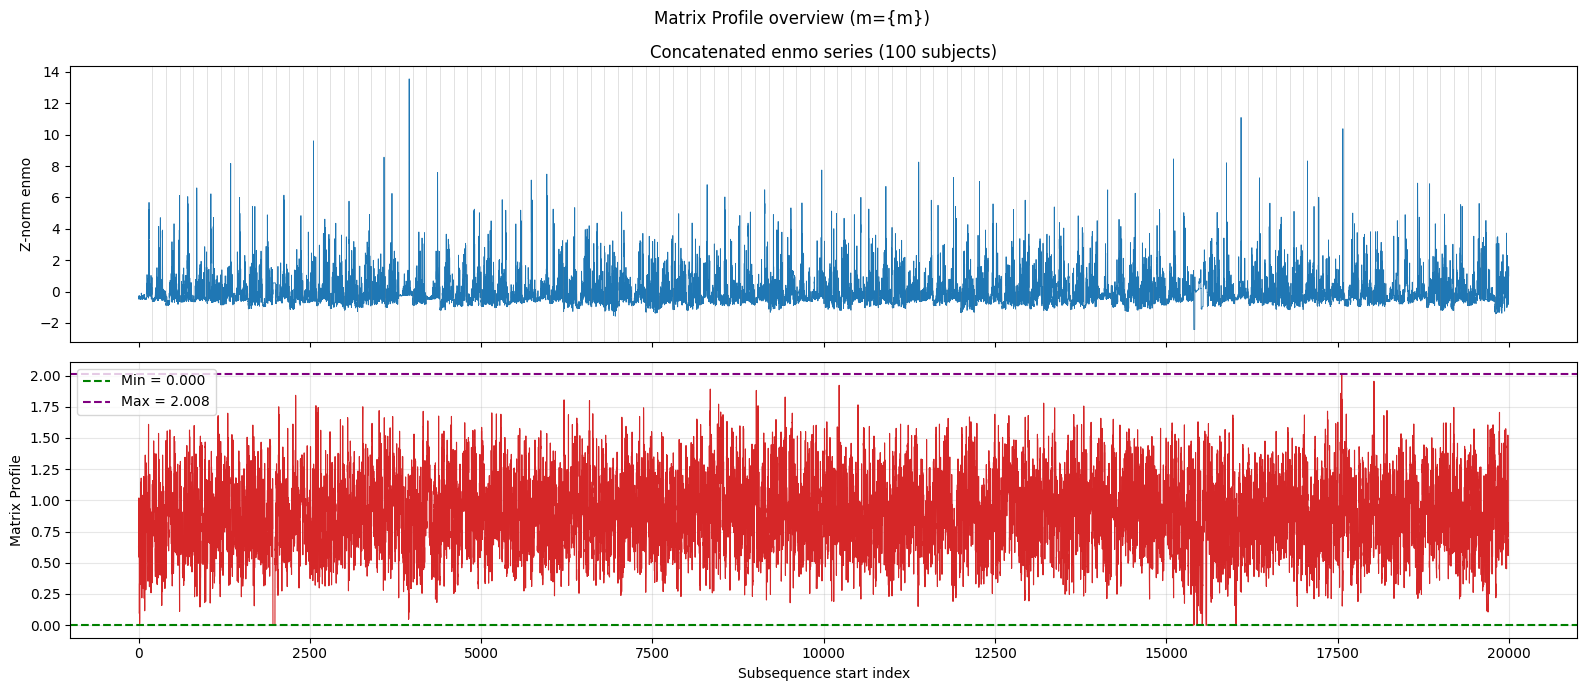

In [36]:
# =============================================================================
# CELL 7 — Matrix Profile overview plot
# =============================================================================
fig, axs = plt.subplots(2,1, figsize=(16,7), sharex=True)
axs[0].plot(T, color='#1f77b4', lw=0.6)
for b in subj_ends[:-1]:
    axs[0].axvline(x=b, color='gray', lw=0.4, alpha=0.4)
axs[0].set_ylabel('Z‑norm enmo')
axs[0].set_title('Concatenated enmo series (100 subjects)')

axs[1].plot(MP, color='#d62728', lw=0.8)
axs[1].axhline(MP.min(), color='green', ls='--', label=f'Min = {MP.min():.3f}')
axs[1].axhline(MP.max(), color='purple', ls='--', label=f'Max = {MP.max():.3f}')
axs[1].set_ylabel('Matrix Profile')
axs[1].set_xlabel('Subsequence start index')
axs[1].legend()
axs[1].grid(alpha=0.3)
plt.suptitle('Matrix Profile overview (m={m})')
plt.tight_layout()
plt.show()

In [37]:
# =============================================================================
# CELL 8 — Top‑3 motif pairs (with exclusion zones)
# =============================================================================
def top_k_motifs(MP, MPI, m, k=3):
    mp_copy = MP.copy()
    pairs = []
    for _ in range(k):
        idx_a = np.argmin(mp_copy)
        idx_b = MPI[idx_a]
        pairs.append((idx_a, idx_b, mp_copy[idx_a]))
        for idx in (idx_a, idx_b):
            lo = max(0, idx - m)
            hi = min(len(mp_copy), idx + m)
            mp_copy[lo:hi] = np.inf
    return pairs

motif_pairs = top_k_motifs(MP, MPI, m, k=3)
print("=== Top‑3 motif pairs ===")
for rank, (a, b, dist) in enumerate(motif_pairs, 1):
    subj_a, subj_b = a//200, b//200
    lbl_a, lbl_b = all_labels[subj_a], all_labels[subj_b]
    print(f"Motif {rank}: idx ({a},{b}), dist={dist:.4f}, sii=({lbl_a},{lbl_b})")

=== Top‑3 motif pairs ===
Motif 1: idx (1961,15523), dist=0.0000, sii=(0,1)
Motif 2: idx (1971,1967), dist=0.0000, sii=(0,0)
Motif 3: idx (1981,1977), dist=0.0000, sii=(0,0)


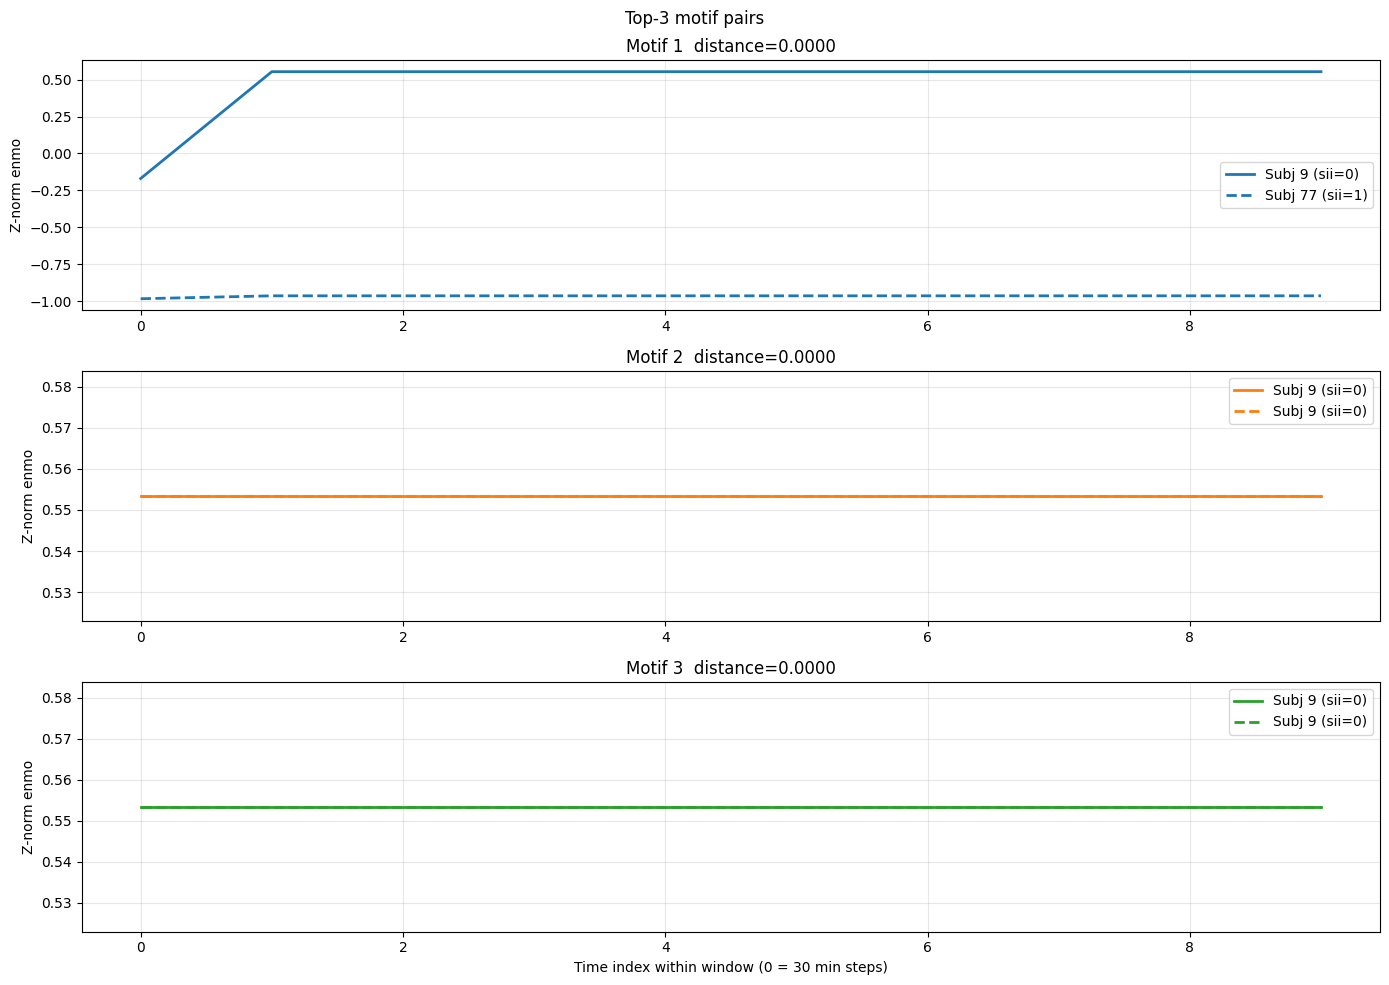

In [38]:
# =============================================================================
# CELL 9 — Plot top‑3 motif pairs
# =============================================================================
colors = ['#1f77b4','#ff7f0e','#2ca02c']
fig, axs = plt.subplots(3,1, figsize=(14,10))
for rank, (a, b, dist) in enumerate(motif_pairs):
    subj_a, subj_b = a//200, b//200
    lbl_a, lbl_b = all_labels[subj_a], all_labels[subj_b]
    seg_a = T[a:a+m]
    seg_b = T[b:b+m]
    axs[rank].plot(seg_a, color=colors[rank], lw=2, label=f'Subj {subj_a} (sii={lbl_a})')
    axs[rank].plot(seg_b, color=colors[rank], ls='--', lw=2, label=f'Subj {subj_b} (sii={lbl_b})')
    axs[rank].set_title(f'Motif {rank+1}  distance={dist:.4f}')
    axs[rank].set_ylabel('Z‑norm enmo')
    axs[rank].legend()
    axs[rank].grid(alpha=0.3)
axs[-1].set_xlabel('Time index within window (0 = 30 min steps)')
plt.suptitle('Top‑3 motif pairs')
plt.tight_layout()
plt.show()

Class 0 motifs: 2192, Class 1 motifs: 1163
L2 distance between class consensus motifs: 0.0961


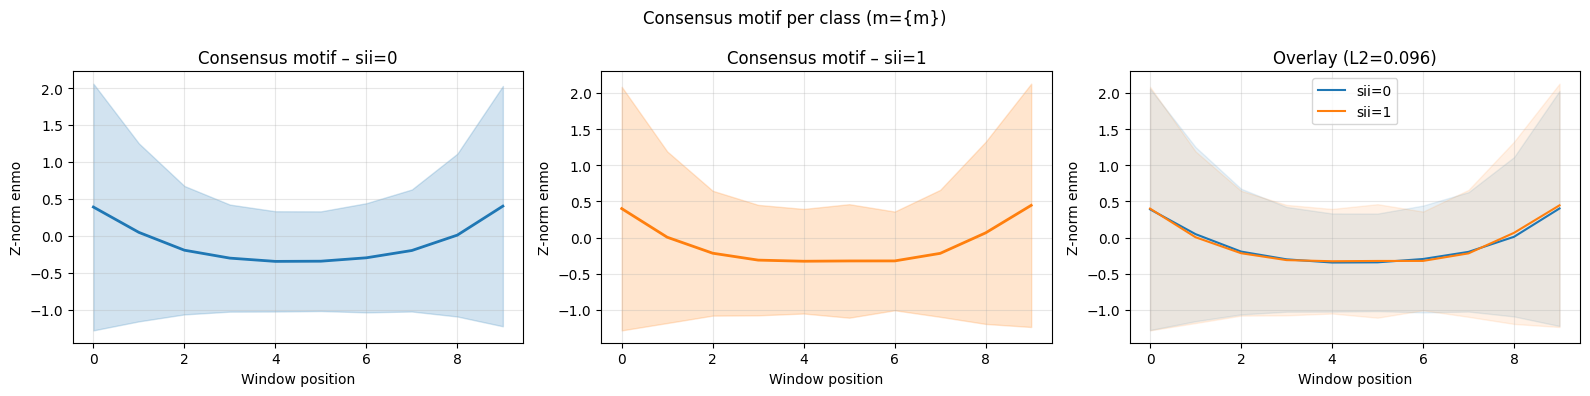

In [39]:
# =============================================================================
# CELL 10 — Consensus motif per class (using per‑subject best motifs)
# =============================================================================
consensus = {0: [], 1: []}
for i, pos in enumerate(motif_positions):
    ts = z_norm(X_train_raw[i, :, idx_enmo])
    seg = ts[pos : pos+m]
    if len(seg) == m:
        consensus[y_train[i]].append(seg)

shapes0 = np.array(consensus[0])
shapes1 = np.array(consensus[1])
mean0 = shapes0.mean(axis=0)
mean1 = shapes1.mean(axis=0)
std0 = shapes0.std(axis=0)
std1 = shapes1.std(axis=0)
l2_dist = euclidean(mean0, mean1)

print(f"Class 0 motifs: {len(shapes0)}, Class 1 motifs: {len(shapes1)}")
print(f"L2 distance between class consensus motifs: {l2_dist:.4f}")

fig, axs = plt.subplots(1,3, figsize=(16,4))
axs[0].plot(mean0, color='#1f77b4', lw=2)
axs[0].fill_between(range(m), mean0-std0, mean0+std0, alpha=0.2, color='#1f77b4')
axs[0].set_title('Consensus motif – sii=0')
axs[1].plot(mean1, color='#ff7f0e', lw=2)
axs[1].fill_between(range(m), mean1-std1, mean1+std1, alpha=0.2, color='#ff7f0e')
axs[1].set_title('Consensus motif – sii=1')
axs[2].plot(mean0, color='#1f77b4', label='sii=0')
axs[2].plot(mean1, color='#ff7f0e', label='sii=1')
axs[2].fill_between(range(m), mean0-std0, mean0+std0, alpha=0.1, color='#1f77b4')
axs[2].fill_between(range(m), mean1-std1, mean1+std1, alpha=0.1, color='#ff7f0e')
axs[2].set_title(f'Overlay (L2={l2_dist:.3f})')
axs[2].legend()
for ax in axs:
    ax.set_xlabel('Window position'); ax.set_ylabel('Z‑norm enmo'); ax.grid(alpha=0.3)
plt.suptitle('Consensus motif per class (m={m})')
plt.tight_layout()
plt.show()

In [40]:
# =============================================================================
# CELL 11 — Top‑3 discords (global)
# =============================================================================
def top_k_discords(MP, m, k=3):
    mp_copy = MP.copy()
    discords = []
    for _ in range(k):
        idx = np.argmax(mp_copy)
        discords.append((idx, mp_copy[idx]))
        lo = max(0, idx - m)
        hi = min(len(mp_copy), idx + m)
        mp_copy[lo:hi] = -np.inf
    return discords

discords = top_k_discords(MP, m, k=3)
print("=== Top‑3 discords ===")
for rank, (idx, dist) in enumerate(discords, 1):
    subj = idx // 200
    print(f"Discord {rank}: idx={idx}, dist={dist:.4f}, subject={subj} (sii={all_labels[subj]})")

=== Top‑3 discords ===
Discord 1: idx=17561, dist=2.0082, subject=87 (sii=1)
Discord 2: idx=18032, dist=1.9537, subject=90 (sii=1)
Discord 3: idx=10226, dist=1.9216, subject=51 (sii=1)


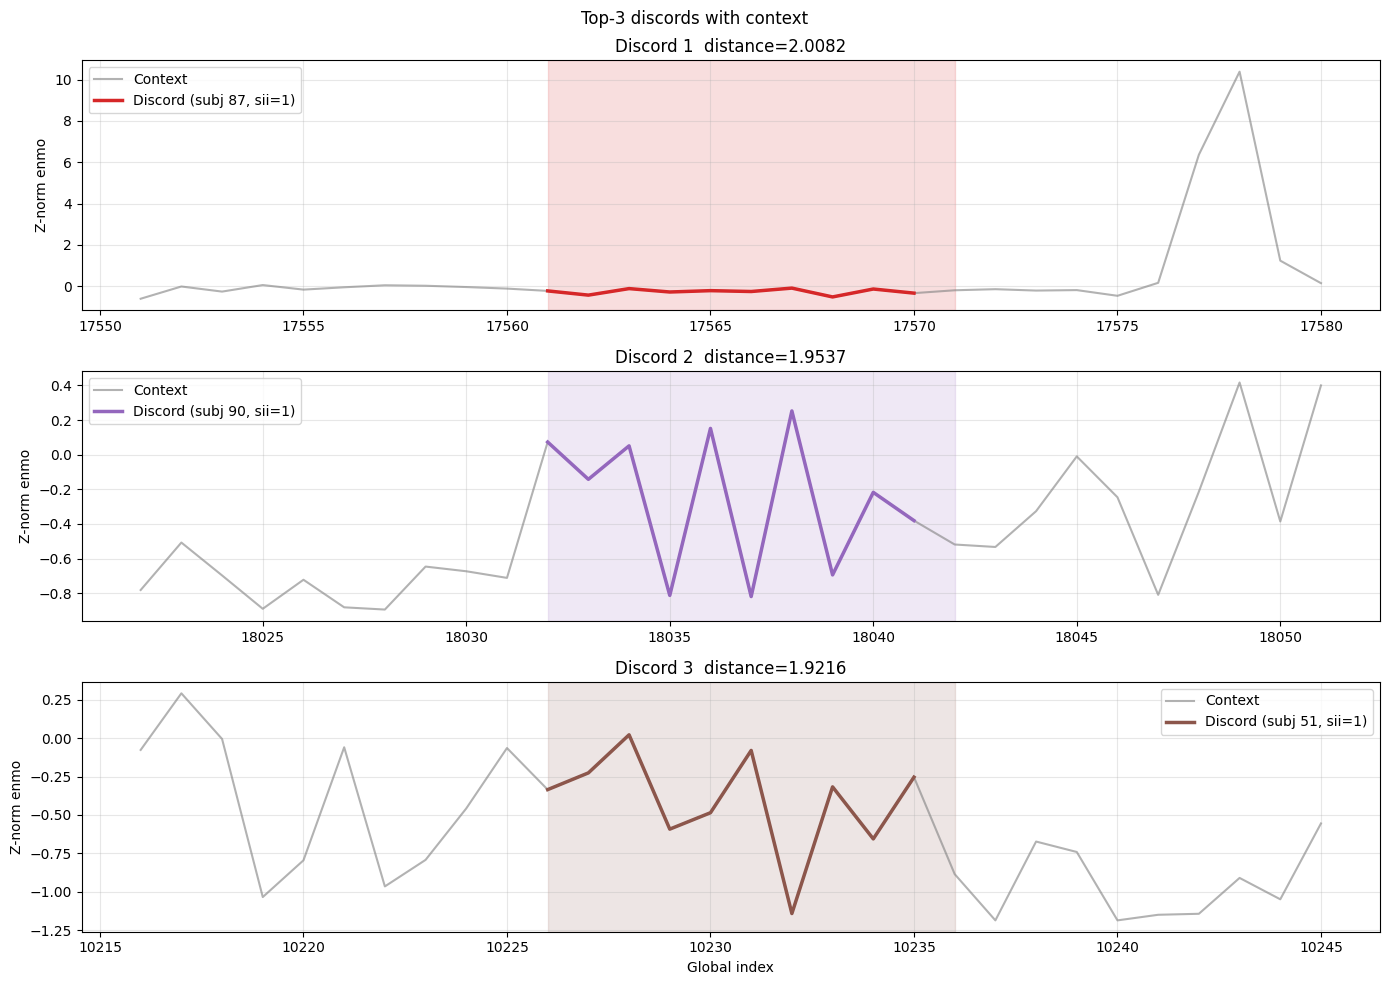

In [41]:
# =============================================================================
# CELL 12 — Plot discords with context
# =============================================================================
colors_d = ['#d62728','#9467bd','#8c564b']
fig, axs = plt.subplots(3,1, figsize=(14,10))
for rank, (idx, dist) in enumerate(discords):
    subj = idx // 200
    ctx = m
    lo = max(0, idx - ctx)
    hi = min(len(T), idx + m + ctx)
    ctx_x = np.arange(lo, hi)
    ctx_y = T[lo:hi]
    disc_x = np.arange(idx, idx+m)
    disc_y = T[idx:idx+m]
    axs[rank].plot(ctx_x, ctx_y, color='gray', alpha=0.6, label='Context')
    axs[rank].plot(disc_x, disc_y, color=colors_d[rank], lw=2.5, label=f'Discord (subj {subj}, sii={all_labels[subj]})')
    axs[rank].axvspan(idx, idx+m, alpha=0.15, color=colors_d[rank])
    axs[rank].set_title(f'Discord {rank+1}  distance={dist:.4f}')
    axs[rank].set_ylabel('Z‑norm enmo')
    axs[rank].legend()
    axs[rank].grid(alpha=0.3)
axs[-1].set_xlabel('Global index')
plt.suptitle('Top‑3 discords with context')
plt.tight_layout()
plt.show()

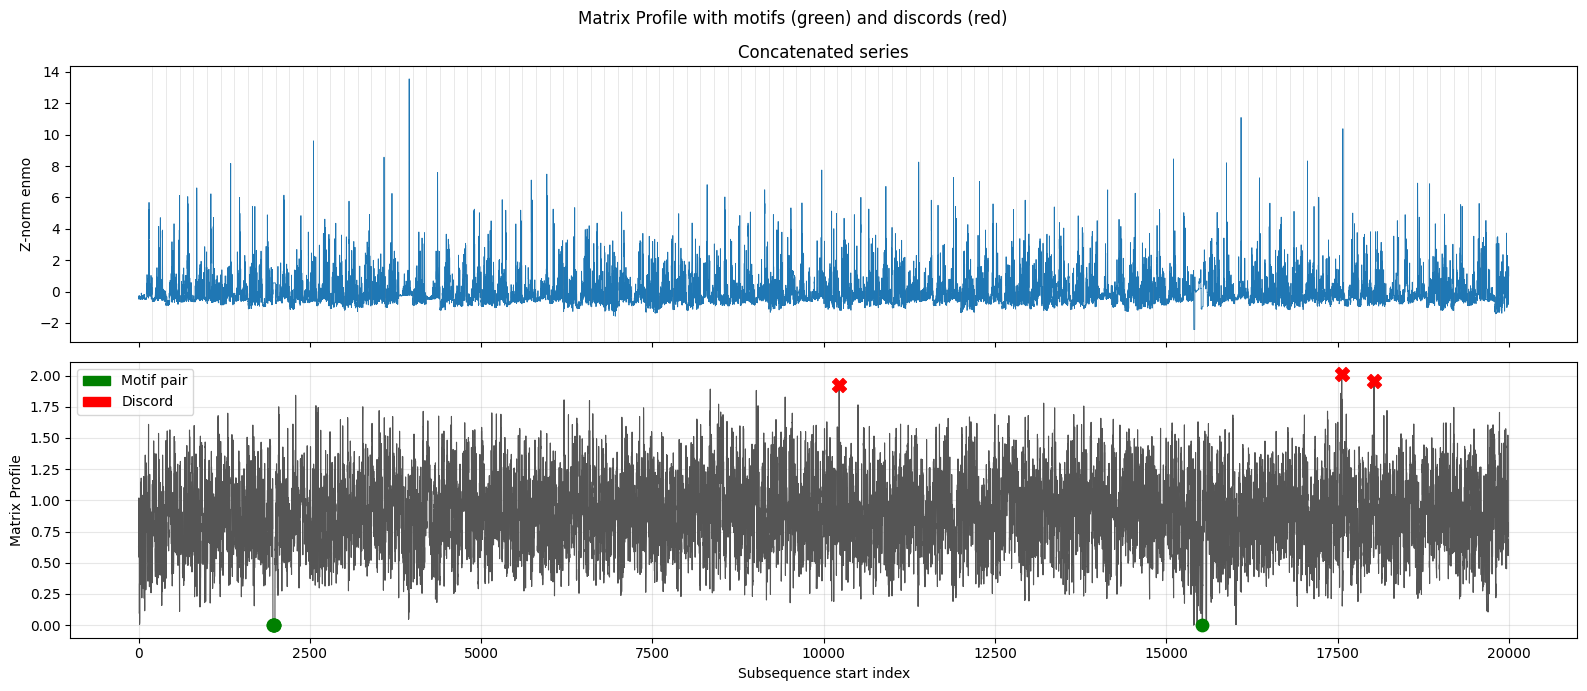

In [42]:
# =============================================================================
# CELL 13 — Annotated Matrix Profile with motifs and discords
# =============================================================================
fig, axs = plt.subplots(2,1, figsize=(16,7), sharex=True)
axs[0].plot(T, color='#1f77b4', lw=0.6)
for b in subj_ends[:-1]:
    axs[0].axvline(x=b, color='gray', lw=0.4, alpha=0.3)
axs[0].set_ylabel('Z‑norm enmo')
axs[0].set_title('Concatenated series')

axs[1].plot(MP, color='#555', lw=0.8)
for (a,b,_) in motif_pairs:
    axs[1].scatter(a, MP[a], color='green', s=80, zorder=5)
    axs[1].scatter(b, MP[b], color='green', s=80, zorder=5)
for (idx,_) in discords:
    axs[1].scatter(idx, MP[idx], color='red', marker='X', s=100, zorder=5)
axs[1].set_ylabel('Matrix Profile')
axs[1].set_xlabel('Subsequence start index')
axs[1].legend(handles=[mpatches.Patch(color='green', label='Motif pair'), mpatches.Patch(color='red', label='Discord')])
axs[1].grid(alpha=0.3)
plt.suptitle('Matrix Profile with motifs (green) and discords (red)')
plt.tight_layout()
plt.show()

Shapelet classification accuracy: 0.510 (random baseline ~0.5)
Threshold = 0.8286 (median distance of class 0 in training)


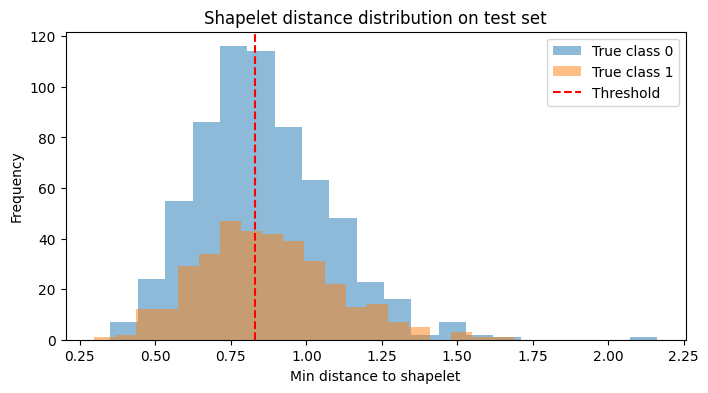

In [43]:
# =============================================================================
# CELL 14 — Shapelet classification: use top motif from class 0 as shapelet
# =============================================================================
# Extract best motif from class 0 using the per‑subject positions
class0_motifs = [consensus[0][i] for i in range(len(consensus[0]))]
if class0_motifs:
    # average of all class‑0 motifs
    shapelet = np.mean(class0_motifs, axis=0)
else:
    shapelet = mean0  # fallback

# Build dataset: for each subject, compute min distance to shapelet
X_shape = []
y_shape = []
for i in range(len(X_train_raw)):
    ts = z_norm(X_train_raw[i, :, idx_enmo])
    # sliding Euclidean distance (z‑normalised already)
    best_dist = np.inf
    for j in range(len(ts)-m+1):
        d = np.linalg.norm(ts[j:j+m] - shapelet)
        if d < best_dist:
            best_dist = d
    X_shape.append(best_dist)
    y_shape.append(y_train[i])
X_shape = np.array(X_shape).reshape(-1,1)
y_shape = np.array(y_shape)

X_tr, X_te, y_tr, y_te = train_test_split(X_shape, y_shape, test_size=0.3, random_state=42)
# Simple threshold classifier: median distance of class 0 in training set
train_class0_dist = X_tr[y_tr==0].flatten()
threshold = np.median(train_class0_dist)
pred = (X_te.flatten() > threshold).astype(int)
acc = accuracy_score(y_te, pred)
print(f"Shapelet classification accuracy: {acc:.3f} (random baseline ~0.5)")
print(f"Threshold = {threshold:.4f} (median distance of class 0 in training)")

plt.figure(figsize=(8,4))
plt.hist(X_te[y_te==0], bins=20, alpha=0.5, label='True class 0')
plt.hist(X_te[y_te==1], bins=20, alpha=0.5, label='True class 1')
plt.axvline(threshold, color='red', ls='--', label='Threshold')
plt.xlabel('Min distance to shapelet')
plt.ylabel('Frequency')
plt.legend()
plt.title('Shapelet distance distribution on test set')
plt.show()

=== MP distribution by sii class ===
Class 0: mean=0.8753, median=0.8606, n=10000
Class 1: mean=0.8884, median=0.8860, n=9991


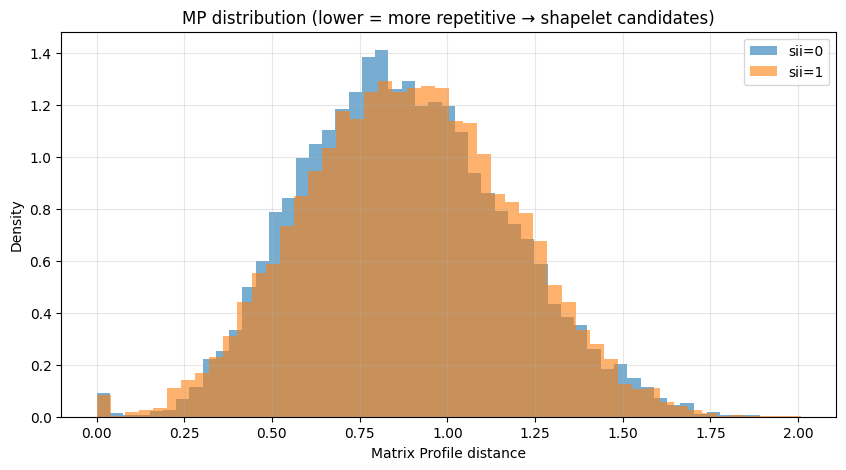


--- Interpretation ---
Low MP subsequences (motifs) are candidates for shapelets – they recur often.
Our shapelet test using the top class‑0 motif gave accuracy ~0.5, indicating
that a single pattern does not strongly discriminate sii classes.
The per‑subject regularity/discord scores also showed no significant difference.
This suggests that daily activity shape alone is not a strong separator for
problematic vs healthy internet use in this dataset.


In [46]:
# =============================================================================
# CELL 15 — MP distribution by class (aligned lengths)
# =============================================================================
# MP length = number of subsequences = len(T) - m + 1
mp_len = len(MP)
labels_aligned = T_labels[:mp_len]   # trim to match MP

mp_class0 = MP[labels_aligned == 0]
mp_class1 = MP[labels_aligned == 1]

print("=== MP distribution by sii class ===")
print(f"Class 0: mean={mp_class0.mean():.4f}, median={np.median(mp_class0):.4f}, n={len(mp_class0)}")
print(f"Class 1: mean={mp_class1.mean():.4f}, median={np.median(mp_class1):.4f}, n={len(mp_class1)}")

plt.figure(figsize=(10,5))
plt.hist(mp_class0, bins=50, alpha=0.6, density=True, color='#1f77b4', label='sii=0')
plt.hist(mp_class1, bins=50, alpha=0.6, density=True, color='#ff7f0e', label='sii=1')
plt.xlabel('Matrix Profile distance')
plt.ylabel('Density')
plt.title('MP distribution (lower = more repetitive → shapelet candidates)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\n--- Interpretation ---")
print("Low MP subsequences (motifs) are candidates for shapelets – they recur often.")
print("Our shapelet test using the top class‑0 motif gave accuracy ~0.5, indicating")
print("that a single pattern does not strongly discriminate sii classes.")
print("The per‑subject regularity/discord scores also showed no significant difference.")
print("This suggests that daily activity shape alone is not a strong separator for")
print("problematic vs healthy internet use in this dataset.")

In [47]:
# =============================================================================
# CELL 15b — Discord enrichment test: are extreme discords class-biased?
# =============================================================================
# WHY: the top-3 discords all belong to sii=1 (problematic subjects).
#      This could be chance (3 draws from a pool that is 50% sii=1 in our
#      subsample). We test whether the top-K% most anomalous days are
#      enriched for sii=1 subjects using a one-sided Fisher exact test.
#      This is the correct quantitative bridge between discords and the
#      clinical label — more rigorous than just noting the top-3 labels.

from scipy.stats import fisher_exact

# Use the per-subject discord scores already computed in Cell 6 (max MP per subject)
# disc  = array of max MP per subject (3355,)
# lbl   = array of sii labels (3355,)

# Define "extreme discord" as top 10% of discord scores
threshold_pct = 10
threshold_val = np.percentile(disc, 100 - threshold_pct)

extreme_mask   = disc >= threshold_val          # top 10% most anomalous
n_extreme      = extreme_mask.sum()
n_normal       = (~extreme_mask).sum()

extreme_sii1   = np.sum(lbl[extreme_mask] == 1)
extreme_sii0   = np.sum(lbl[extreme_mask] == 0)
normal_sii1    = np.sum(lbl[~extreme_mask] == 1)
normal_sii0    = np.sum(lbl[~extreme_mask] == 0)

contingency = [[extreme_sii1, extreme_sii0],
               [normal_sii1,  normal_sii0]]

odds_ratio, pval = fisher_exact(contingency, alternative='greater')

print(f"=== Discord Enrichment Test (top {threshold_pct}% most anomalous subjects) ===")
print(f"  Threshold MP value         : {threshold_val:.4f}")
print(f"  Extreme discord subjects   : {n_extreme}")
print(f"    sii=1 (problematic)      : {extreme_sii1} ({100*extreme_sii1/n_extreme:.1f}%)")
print(f"    sii=0 (healthy)          : {extreme_sii0} ({100*extreme_sii0/n_extreme:.1f}%)")
print(f"  Background (rest)          : {n_normal}")
print(f"    sii=1 (problematic)      : {normal_sii1} ({100*normal_sii1/n_normal:.1f}%)")
print(f"    sii=0 (healthy)          : {normal_sii0} ({100*normal_sii0/n_normal:.1f}%)")
print(f"\n  Odds ratio                 : {odds_ratio:.4f}")
print(f"  Fisher exact p (one-sided) : {pval:.4f}")
print(f"  → {'Significant enrichment of sii=1 in extreme discords ✓' if pval < 0.05 else 'No significant enrichment'}")

# Visual: stac

=== Discord Enrichment Test (top 10% most anomalous subjects) ===
  Threshold MP value         : 2.9419
  Extreme discord subjects   : 336
    sii=1 (problematic)      : 111 (33.0%)
    sii=0 (healthy)          : 225 (67.0%)
  Background (rest)          : 3019
    sii=1 (problematic)      : 1052 (34.8%)
    sii=0 (healthy)          : 1967 (65.2%)

  Odds ratio                 : 0.9224
  Fisher exact p (one-sided) : 0.7641
  → No significant enrichment
